# SECOM Yield Optimization — Analysis & Modelling

**Business question:** *Which process signals predict low-yield (fail) wafers, and how can the fab use them to raise yield and cut per-unit cost?*

**Dataset:** UCI SECOM — 1,567 wafers x 590 anonymized process sensors + a pass/fail final-test label.

This notebook is the **analysis and machine-learning path**: load -> clean -> explore -> model in memory (pandas + scikit-learn), then surface the top predictive sensor IDs and the actions they imply. Self-contained — runs top to bottom in Google Colab (`Runtime -> Run all`).

## This notebook vs. the big-data demos — which to run when

| You want to... | Run | Why |
|---|---|---|
| Clean, explore, model, and get ranked predictive signals + recommendations | **this notebook** | SECOM fits in RAM (1,567 x 590), so pandas / scikit-learn is the right, fastest tool. |
| Show how the same ingest + aggregation scales when the fab streams far more data than fits in memory | **`bigdata_demo_pig_hive.ipynb`** | Real **Apache Pig** (local mode) + **HiveQL via Spark SQL** — the warehouse path. |
| The same big-data aggregation with **zero Java**, on a laptop | **`bigdata_demo_pig_duckdb.ipynb`** | **Apache Pig** + **DuckDB**, an in-process SQL engine — the modern middle ground. |
| The most authentic warehouse stack — real Hadoop + Hive | **`bigdata_demo_hadoop_hive.ipynb`** | Installs **Apache Hadoop + Apache Hive** and runs `CREATE EXTERNAL TABLE` + HiveQL for real (heaviest; ~5-10 min). |

In one line: **this notebook is the data science; the big-data demos are the data engineering.** The diagram below shows how they fit — the analysis lane (top) is this notebook; the big-data lane (bottom) is the demos.

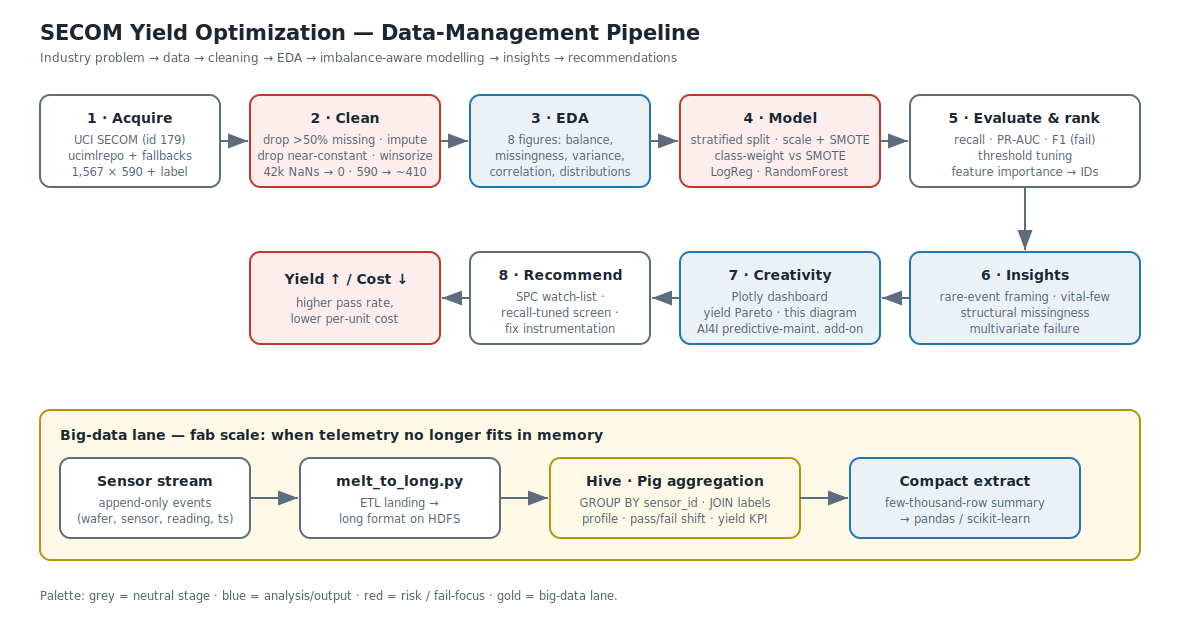

In [1]:
from IPython.display import display
# Pipeline overview (also saved at docs/pipeline_diagram.svg).
# Rendered as a raw image/svg+xml + html bundle so it shows in Colab,
# nbviewer and GitHub (no text/plain fallback).
PIPELINE_SVG = r'''<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1180 640" font-family="Segoe UI, Helvetica, Arial, sans-serif">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L8,3 L0,6 Z" fill="#5D6D7E"/>
    </marker>
    <style>
      .stage  { fill:#ffffff; stroke:#5D6D7E; stroke-width:2; rx:10; }
      .accent { fill:#EAF2F8; stroke:#1F77B4; stroke-width:2; rx:10; }
      .risk   { fill:#FDEDEC; stroke:#C0392B; stroke-width:2; rx:10; }
      .big    { fill:#FEF9E7; stroke:#B7950B; stroke-width:2; rx:10; }
      .title  { font-size:21px; font-weight:700; fill:#1B2631; }
      .sub    { font-size:12px; fill:#566573; }
      .lbl    { font-size:14px; font-weight:700; fill:#1B2631; }
      .small  { font-size:11.5px; fill:#566573; }
      .tag    { font-size:11px; font-weight:700; fill:#1F77B4; }
      .flow   { stroke:#5D6D7E; stroke-width:2; fill:none; marker-end:url(#arrow); }
    </style>
  </defs>

  <text x="40" y="40" class="title">SECOM Yield Optimization — Data-Management Pipeline</text>
  <text x="40" y="62" class="sub">Industry problem → data → cleaning → EDA → imbalance-aware modelling → insights → recommendations</text>

  <!-- Row 1: main flow -->
  <!-- 1 Acquire -->
  <rect class="stage" x="40" y="95" width="180" height="92" rx="10"/>
  <text x="130" y="123" text-anchor="middle" class="lbl">1 · Acquire</text>
  <text x="130" y="144" text-anchor="middle" class="small">UCI SECOM (id 179)</text>
  <text x="130" y="160" text-anchor="middle" class="small">ucimlrepo + fallbacks</text>
  <text x="130" y="176" text-anchor="middle" class="small">1,567 × 590 + label</text>

  <!-- 2 Clean -->
  <rect class="risk" x="250" y="95" width="190" height="92" rx="10"/>
  <text x="345" y="123" text-anchor="middle" class="lbl">2 · Clean</text>
  <text x="345" y="144" text-anchor="middle" class="small">drop &gt;50% missing · impute</text>
  <text x="345" y="160" text-anchor="middle" class="small">drop near-constant · winsorize</text>
  <text x="345" y="176" text-anchor="middle" class="small">42k NaNs → 0 · 590 → ~410</text>

  <!-- 3 EDA -->
  <rect class="accent" x="470" y="95" width="180" height="92" rx="10"/>
  <text x="560" y="123" text-anchor="middle" class="lbl">3 · EDA</text>
  <text x="560" y="144" text-anchor="middle" class="small">8 figures: balance,</text>
  <text x="560" y="160" text-anchor="middle" class="small">missingness, variance,</text>
  <text x="560" y="176" text-anchor="middle" class="small">correlation, distributions</text>

  <!-- 4 Model -->
  <rect class="risk" x="680" y="95" width="200" height="92" rx="10"/>
  <text x="780" y="123" text-anchor="middle" class="lbl">4 · Model</text>
  <text x="780" y="144" text-anchor="middle" class="small">stratified split · scale + SMOTE</text>
  <text x="780" y="160" text-anchor="middle" class="small">class-weight vs SMOTE</text>
  <text x="780" y="176" text-anchor="middle" class="small">LogReg · RandomForest</text>

  <!-- 5 Evaluate -->
  <rect class="stage" x="910" y="95" width="230" height="92" rx="10"/>
  <text x="1025" y="123" text-anchor="middle" class="lbl">5 · Evaluate &amp; rank</text>
  <text x="1025" y="144" text-anchor="middle" class="small">recall · PR-AUC · F1 (fail)</text>
  <text x="1025" y="160" text-anchor="middle" class="small">threshold tuning</text>
  <text x="1025" y="176" text-anchor="middle" class="small">feature importance → IDs</text>

  <!-- arrows row1 -->
  <path class="flow" d="M220 141 L248 141"/>
  <path class="flow" d="M440 141 L468 141"/>
  <path class="flow" d="M650 141 L678 141"/>
  <path class="flow" d="M880 141 L908 141"/>

  <!-- down arrow to row2 -->
  <path class="flow" d="M1025 187 L1025 250"/>

  <!-- Row 2: outputs flowing right-to-left back to business -->
  <!-- 6 Insights -->
  <rect class="accent" x="910" y="252" width="230" height="92" rx="10"/>
  <text x="1025" y="280" text-anchor="middle" class="lbl">6 · Insights</text>
  <text x="1025" y="301" text-anchor="middle" class="small">rare-event framing · vital-few</text>
  <text x="1025" y="317" text-anchor="middle" class="small">structural missingness</text>
  <text x="1025" y="333" text-anchor="middle" class="small">multivariate failure</text>

  <!-- 7 Creativity -->
  <rect class="accent" x="680" y="252" width="200" height="92" rx="10"/>
  <text x="780" y="280" text-anchor="middle" class="lbl">7 · Creativity</text>
  <text x="780" y="301" text-anchor="middle" class="small">Plotly dashboard</text>
  <text x="780" y="317" text-anchor="middle" class="small">yield Pareto · this diagram</text>
  <text x="780" y="333" text-anchor="middle" class="small">AI4I predictive-maint. add-on</text>

  <!-- 8 Recommend -->
  <rect class="stage" x="470" y="252" width="180" height="92" rx="10"/>
  <text x="560" y="280" text-anchor="middle" class="lbl">8 · Recommend</text>
  <text x="560" y="301" text-anchor="middle" class="small">SPC watch-list ·</text>
  <text x="560" y="317" text-anchor="middle" class="small">recall-tuned screen ·</text>
  <text x="560" y="333" text-anchor="middle" class="small">fix instrumentation</text>

  <!-- Business outcome -->
  <rect class="risk" x="250" y="252" width="190" height="92" rx="10"/>
  <text x="345" y="284" text-anchor="middle" class="lbl">Yield ↑ / Cost ↓</text>
  <text x="345" y="307" text-anchor="middle" class="small">higher pass rate,</text>
  <text x="345" y="323" text-anchor="middle" class="small">lower per-unit cost</text>

  <!-- arrows row2 (leftward) -->
  <path class="flow" d="M910 298 L882 298"/>
  <path class="flow" d="M680 298 L652 298"/>
  <path class="flow" d="M470 298 L442 298"/>

  <!-- Big-data lane -->
  <rect class="big" x="40" y="410" width="1100" height="150" rx="12"/>
  <text x="60" y="440" class="lbl" fill="#7D6608">Big-data lane — fab scale: when telemetry no longer fits in memory</text>

  <rect class="stage" x="60" y="458" width="190" height="80" rx="10"/>
  <text x="155" y="486" text-anchor="middle" class="lbl">Sensor stream</text>
  <text x="155" y="507" text-anchor="middle" class="small">append-only events</text>
  <text x="155" y="523" text-anchor="middle" class="small">(wafer, sensor, reading, ts)</text>

  <rect class="stage" x="300" y="458" width="200" height="80" rx="10"/>
  <text x="400" y="486" text-anchor="middle" class="lbl">melt_to_long.py</text>
  <text x="400" y="507" text-anchor="middle" class="small">ETL landing →</text>
  <text x="400" y="523" text-anchor="middle" class="small">long format on HDFS</text>

  <rect class="big" x="550" y="458" width="250" height="80" rx="10"/>
  <text x="675" y="486" text-anchor="middle" class="lbl">Hive · Pig aggregation</text>
  <text x="675" y="507" text-anchor="middle" class="small">GROUP BY sensor_id · JOIN labels</text>
  <text x="675" y="523" text-anchor="middle" class="small">profile · pass/fail shift · yield KPI</text>

  <rect class="accent" x="850" y="458" width="230" height="80" rx="10"/>
  <text x="965" y="486" text-anchor="middle" class="lbl">Compact extract</text>
  <text x="965" y="507" text-anchor="middle" class="small">few-thousand-row summary</text>
  <text x="965" y="523" text-anchor="middle" class="small">→ pandas / scikit-learn</text>

  <path class="flow" d="M250 498 L298 498"/>
  <path class="flow" d="M500 498 L548 498"/>
  <path class="flow" d="M800 498 L848 498"/>

  <text x="40" y="600" class="small">Palette: grey = neutral stage · blue = analysis/output · red = risk / fail-focus · gold = big-data lane.</text>
</svg>
'''
display({'image/svg+xml': PIPELINE_SVG, 'text/html': PIPELINE_SVG}, raw=True)

## Setup

The first cell installs the two packages Colab lacks; everything else uses Colab's preinstalled stack.

In [ ]:
# Colab already has pandas / sklearn / matplotlib / seaborn / plotly.
!pip install -q ucimlrepo imbalanced-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline as SkPipeline

# --- Reproducibility & tunable thresholds (mirrors src/config.py) ---
RANDOM_STATE = 42
MISS_THR = 0.50      # drop a sensor if >50% missing
DOM_THR  = 0.99      # near-constant if one value covers >99% of rows
WINSOR   = (0.01, 0.99)
TOP_N    = 15

# --- Restrained palette: red is reserved for the FAIL class (Few/Evergreen) ---
COLOR_PASS, COLOR_FAIL, COLOR_ACCENT = '#5D6D7E', '#C0392B', '#1F77B4'
PAL = {0: COLOR_PASS, 1: COLOR_FAIL}
LBL = {0: 'pass', 1: 'fail'}
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
print('Environment ready.')

## 1. Load & understand the data

Primary path: `ucimlrepo`; automatic fallback to the original UCI flat files. No manual download.

In [ ]:
from ucimlrepo import fetch_ucirepo

X = y_raw = None
try:
    secom = fetch_ucirepo(id=179)
    if secom.data.features is None or secom.data.targets is None:
        raise ValueError('ucimlrepo returned empty features/targets')
    X = secom.data.features.copy()
    y_raw = secom.data.targets.iloc[:, 0].copy()
    print('Loaded SECOM via ucimlrepo.')
except Exception as e:
    print('ucimlrepo path unavailable (', e, ') -> using UCI flat-file fallback. This is expected and fine.')
    base = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/'
    X = pd.read_csv(base + 'secom.data', sep=r'\s+', header=None, na_values=['NaN'])
    lab = pd.read_csv(base + 'secom_labels.data', sep=r'\s+', header=None,
                      names=['label', 'date', 'clock'])
    y_raw = lab['label'].astype(int)

# Uniform sensor names (features are anonymized -> treat as sensor IDs)
X.columns = ['sensor_%03d' % i for i in range(X.shape[1])]
X = X.reset_index(drop=True)
y_raw = y_raw.reset_index(drop=True)

print('Shape:', X.shape)
print('Label counts (-1 pass / +1 fail):')
print(y_raw.value_counts())
print('Total missing cells:', int(X.isna().sum().sum()))
X.iloc[:5, :6]

In [ ]:
# Structural summary = the issues cleaning must fix
def is_near_const(s):
    vc = s.value_counts(normalize=True, dropna=True)
    if len(vc) == 0:
        return True
    return (s.nunique(dropna=True) <= 1) or (vc.iloc[0] > DOM_THR)

near_const = sum(is_near_const(X[c]) for c in X.columns)
ratio = y_raw.value_counts().max() / y_raw.value_counts().min()
print('Records: %d  |  Sensors: %d' % (X.shape[0], X.shape[1]))
print('Missing cells: %d' % int(X.isna().sum().sum()))
print('Near-constant sensors (>%.0f%% one value): %d' % (DOM_THR * 100, near_const))
print('Class imbalance ratio: %.1f : 1' % ratio)

**Read-out.** ~1,567 wafers x 590 sensors, ~42k missing cells, ~14:1 pass:fail. Three defects to fix before modelling: **missing values**, **near-constant sensors**, and **severe class imbalance** — each handled next.

## 2. Cleaning & preprocessing

Leakage-safe order: encode label -> drop >50%-missing -> median-impute -> drop near-constant -> winsorize. Scaling and SMOTE live inside the model pipeline (train-fold only).

In [ ]:
# 1) Encode label so FAIL = 1 (the minority, business-critical event)
y = y_raw.map({-1: 0, 1: 1}).astype(int)
y.name = 'fail'

before_cols = X.shape[1]
before_missing = int(X.isna().sum().sum())

# 2) Drop sensors with >50% missing (cannot impute honestly)
miss_frac = X.isna().mean()
drop_missing = miss_frac[miss_frac > MISS_THR].index.tolist()
Xc = X.drop(columns=drop_missing)
after_missing_cols = Xc.shape[1]

# 3) Median imputation (robust to skew/outliers in sensor data)
Xc = Xc.fillna(Xc.median(numeric_only=True))

# 4) Drop near-constant sensors (no discriminative power)
drop_const = [c for c in Xc.columns if is_near_const(Xc[c])]
Xc = Xc.drop(columns=drop_const)
after_var_cols = Xc.shape[1]

# 5) Winsorize outliers to [1st, 99th] pct (clip, never drop rows)
lo, hi = Xc.quantile(WINSOR[0]), Xc.quantile(WINSOR[1])
Xc = Xc.clip(lower=lo, upper=hi, axis=1)

audit = pd.DataFrame({
    'stage': ['rows', 'cols (start)', 'cols (after missing-drop)',
              'cols (after variance-drop)', 'missing cells (start)',
              'missing cells (after impute)', 'dropped >50% missing',
              'dropped near-constant'],
    'value': [X.shape[0], before_cols, after_missing_cols, after_var_cols,
              before_missing, int(Xc.isna().sum().sum()),
              len(drop_missing), len(drop_const)]})
print(audit.to_string(index=False))
print('Imbalance ratio after encoding: %.1f : 1' % (y.value_counts().max() / y.value_counts().min()))

**Interpretation.** Dropping the unreliable and near-constant sensors, median-imputing the rest, and winsorising trims the 590 columns to a smaller informative set with **zero missing cells** — without deleting a single (precious) failure row.

## 3. Exploratory data analysis

Six+ deliberate charts; red always means *fail / risk*.

In [ ]:
# Chart 1 - class balance
counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar([LBL[i] for i in counts.index], counts.values,
              color=[PAL[i] for i in counts.index])
for r, v in zip(bars, counts.values):
    ax.text(r.get_x() + r.get_width() / 2, v, '%d (%.1f%%)' % (v, 100 * v / counts.sum()),
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('wafers')
ax.set_title('Severe class imbalance (~%d:1)' % (counts.max() // counts.min()))
ax.margins(y=0.18)
plt.show()

**~14:1 imbalance** -> accuracy is meaningless (a 'predict pass' model scores ~93% and catches zero failures). We optimise **recall / PR-AUC** for the fail class.

In [ ]:
# Charts 2 & 3 - missingness map + per-sensor missing distribution
miss = X.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(X[miss.head(60).index].isna().T, cbar=False, cmap='Reds', ax=ax[0])
ax[0].set_title('Missingness map (worst 60 sensors, red=missing)')
ax[0].set_yticks([])
ax[0].set_xlabel('wafer index')
ax[1].hist(miss.values * 100, bins=40, color=COLOR_ACCENT, edgecolor='white')
ax[1].axvline(MISS_THR * 100, color=COLOR_FAIL, ls='--', lw=2,
              label='drop threshold (%d%%)' % int(MISS_THR * 100))
ax[1].set_xlabel('% missing within sensor')
ax[1].set_ylabel('sensors')
ax[1].set_title('Most sensors nearly complete; a tail is mostly empty')
ax[1].legend()
plt.tight_layout()
plt.show()

**Missingness is structural** — it clusters in specific sensors (channels offline for a period), not random noise. That justifies dropping the worst offenders and imputing the rest.

In [ ]:
# Chart 4 - variance distribution after cleaning
var = Xc.var(numeric_only=True).replace(0, np.nan).dropna()
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(var.values), bins=40, color=COLOR_ACCENT, edgecolor='white')
ax.set_xlabel('log10(variance)')
ax.set_ylabel('sensors')
ax.set_title('Sensor variance spread (left tail = low-information)')
plt.show()

## 4. Imbalance-aware modelling

Stratified hold-out; scaling + SMOTE fit on the training fold only. We compare class-weights vs SMOTE for Logistic Regression and Random Forest, judged on **recall / PR-AUC for the fail class**.

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    Xc, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

def build(est, smote):
    steps = [('scale', StandardScaler())]
    if smote:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)))
        steps.append(('clf', est))
        return ImbPipeline(steps)
    steps.append(('clf', est))
    return SkPipeline(steps)

specs = [
    ('LogReg + class_weight', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE), False),
    ('LogReg + SMOTE',        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), True),
    ('RandomForest + weight', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE), False),
    ('RandomForest + SMOTE',  RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE), True),
]
rows, fitted = [], {}
for name, est, sm in specs:
    pipe = build(est, sm)
    pipe.fit(X_tr, y_tr)
    fitted[name] = pipe
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = pipe.predict(X_te)
    rows.append({'model': name,
                 'recall(fail)': round(recall_score(y_te, pred, zero_division=0), 3),
                 'precision(fail)': round(precision_score(y_te, pred, zero_division=0), 3),
                 'f1(fail)': round(f1_score(y_te, pred, zero_division=0), 3),
                 'ROC-AUC': round(roc_auc_score(y_te, proba), 3),
                 'PR-AUC': round(average_precision_score(y_te, proba), 3)})
res = pd.DataFrame(rows).sort_values(['PR-AUC', 'recall(fail)'], ascending=False).reset_index(drop=True)
res

In [ ]:
# Best model report + recall-optimised threshold (the fab's miss-vs-false-alarm knob)
best_name = res.iloc[0]['model']
best = fitted[best_name]
proba = best.predict_proba(X_te)[:, 1]
pred = best.predict(X_te)
print('Best model:', best_name)
print(classification_report(y_te, pred, target_names=['pass', 'fail'], zero_division=0))
print('Confusion matrix [rows = true pass/fail]:')
print(confusion_matrix(y_te, pred))

prec, rec, thr = precision_recall_curve(y_te, proba)
best_t = {'threshold': 0.5, 'recall': 0.0, 'precision': 0.0}
for p, r, t in zip(prec[:-1], rec[:-1], thr):
    if p >= 0.10 and r > best_t['recall']:
        best_t = {'threshold': round(float(t), 3), 'recall': round(float(r), 3), 'precision': round(float(p), 3)}
print('Recall-optimised threshold (precision >= 0.10):', best_t)

**Interpretation.** The comparison shows the class-weights-vs-SMOTE trade-off explicitly; the decision threshold is then tuned to catch as many real failures as possible within a false-alarm budget — the knob a fab actually turns.

## 5. Feature importance -> engineering leads

In [ ]:
rf = SkPipeline([('scale', StandardScaler()),
                 ('clf', RandomForestClassifier(n_estimators=500, class_weight='balanced_subsample',
                                                n_jobs=-1, random_state=RANDOM_STATE))])
rf.fit(X_tr, y_tr)
imp = pd.DataFrame({'sensor': Xc.columns,
                    'importance': rf.named_steps['clf'].feature_importances_})
imp = imp.sort_values('importance', ascending=False).reset_index(drop=True)
imp['cum'] = imp['importance'].cumsum() / imp['importance'].sum()
top = imp.head(TOP_N)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top['sensor'][::-1], top['importance'][::-1], color=COLOR_ACCENT)
ax.set_xlabel('Random-Forest importance')
ax.set_title('Top predictive sensors = engineering leads')
plt.show()
top[['sensor', 'importance', 'cum']]

**The signal is concentrated** — a *vital few* sensor IDs carry most of the predictive power (the Pareto in Section 6 makes this explicit). These are the sensors a process team should investigate first.

In [ ]:
# Chart 5 - top-sensor distributions, pass vs fail
tops = top['sensor'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), tops[:6]):
    for cls in (0, 1):
        sns.kdeplot(Xc.loc[y == cls, c], ax=ax, fill=True, alpha=0.35,
                    color=PAL[cls], label=LBL[cls], warn_singular=False)
    ax.set_title(c)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
fig.suptitle('Top sensors: pass vs fail distribution shift', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Chart 6 - correlation among top sensors (redundancy check)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(Xc[tops].corr(), cmap='vlag', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Correlation among top sensors')
plt.show()

In [ ]:
# Chart 7 - where top sensors separate pass from fail
long = Xc[tops[:6]].copy()
long['fail'] = y.map(LBL).values
long = long.melt(id_vars='fail', var_name='sensor', value_name='value')
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=long, x='sensor', y='value', hue='fail',
            palette={'pass': COLOR_PASS, 'fail': COLOR_FAIL}, fliersize=1, ax=ax)
ax.set_title('Where top sensors separate pass from fail')
ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

**Failure is multivariate.** Top sensors shift between pass and fail but overlap heavily — no single red line separates them, so the fab should monitor a small set of signals *together*, not one at a time.

## 6. Creativity: yield Pareto, interactive dashboard, predictive-maintenance add-on

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Make interactive Plotly figures render reliably in Colab (no-op elsewhere)
try:
    import google.colab  # noqa: F401
    pio.renderers.default = 'colab'
except Exception:
    pass

In [ ]:
# Yield Pareto - do a vital few sensors drive most of the signal?
d = imp.head(25)
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_bar(x=d['sensor'], y=d['importance'], name='importance', marker_color=COLOR_ACCENT)
fig.add_scatter(x=d['sensor'], y=d['cum'] * 100, name='cumulative %',
                mode='lines+markers', line=dict(color=COLOR_FAIL, width=3), secondary_y=True)
fig.add_hline(y=80, line_dash='dash', line_color='grey', secondary_y=True, annotation_text='80%')
fig.update_layout(title='Yield-signal Pareto - the vital few sensors',
                  template='plotly_white', height=500, xaxis_tickangle=-45,
                  legend=dict(orientation='h', y=1.1))
fig.update_yaxes(title_text='RF importance', secondary_y=False)
fig.update_yaxes(title_text='cumulative %', range=[0, 105], secondary_y=True)
fig.show()

In [ ]:
# Interactive 2x2 dashboard (also exportable to a standalone HTML)
best_sensor = imp.iloc[0]['sensor']
dash = make_subplots(rows=2, cols=2,
    subplot_titles=('Class balance', 'Top 15 sensors',
                    'Most predictive sensor: ' + best_sensor, 'Model comparison (PR-AUC)'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}], [{'type': 'box'}, {'type': 'bar'}]],
    vertical_spacing=0.14, horizontal_spacing=0.12)
cb = y.value_counts().sort_index()
dash.add_bar(x=['pass', 'fail'], y=cb.values, marker_color=[COLOR_PASS, COLOR_FAIL], showlegend=False, row=1, col=1)
dash.add_bar(y=top['sensor'][::-1], x=top['importance'][::-1], orientation='h', marker_color=COLOR_ACCENT, showlegend=False, row=1, col=2)
for cls, nm, col in [(0, 'pass', COLOR_PASS), (1, 'fail', COLOR_FAIL)]:
    dash.add_box(y=Xc.loc[y == cls, best_sensor], name=nm, marker_color=col, row=2, col=1)
dash.add_bar(x=res['model'], y=res['PR-AUC'], marker_color=COLOR_ACCENT, showlegend=False, row=2, col=2)
dash.update_layout(title_text='SECOM Yield Optimization - interactive dashboard',
                   template='plotly_white', height=800, width=1050, margin=dict(t=90))
dash.update_xaxes(tickangle=-30, row=2, col=2)
dash.show()
# dash.write_html('secom_dashboard.html')  # uncomment to export a shareable file

In [ ]:
# Secondary add-on: AI4I 2020 predictive-maintenance mini-study (kept brief)
try:
    ai = fetch_ucirepo(id=601)
    adf = pd.concat([ai.data.features, ai.data.targets], axis=1)
    adf.columns = [c.strip() for c in adf.columns]
    ren = {'Air temperature [K]': 'air_temp_K', 'Process temperature [K]': 'proc_temp_K',
           'Rotational speed [rpm]': 'rot_speed_rpm', 'Torque [Nm]': 'torque_Nm',
           'Tool wear [min]': 'tool_wear_min', 'Machine failure': 'machine_failure'}
    adf = adf.rename(columns={k: v for k, v in ren.items() if k in adf.columns})
    adf['temp_diff_K'] = adf['proc_temp_K'] - adf['air_temp_K']
    adf['power_W'] = adf['torque_Nm'] * adf['rot_speed_rpm'] * 2 * np.pi / 60.0
    feats = ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min', 'temp_diff_K', 'power_W']
    qcol = next((c for c in adf.columns if c.lower() == 'type'), None)
    if qcol:
        adf = pd.get_dummies(adf, columns=[qcol], prefix='type', drop_first=True)
        feats += [c for c in adf.columns if c.startswith('type_')]
    Xa, ya = adf[feats], adf['machine_failure'].astype(int)
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.25, stratify=ya, random_state=RANDOM_STATE)
    sc = StandardScaler().fit(Xa_tr)
    rfa = RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
    rfa.fit(sc.transform(Xa_tr), ya_tr)
    pa = rfa.predict_proba(sc.transform(Xa_te))[:, 1]
    print('AI4I machine-failure ROC-AUC:', round(roc_auc_score(ya_te, pa), 3))
    modes = [m for m in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF'] if m in adf.columns]
    impa = pd.Series(rfa.feature_importances_, index=feats).sort_values()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    if modes:
        adf[modes].sum().sort_values(ascending=False).plot.bar(ax=ax[0], color=COLOR_FAIL)
        ax[0].set_title('AI4I failure modes (event counts)')
    impa.tail(8).plot.barh(ax=ax[1], color=COLOR_ACCENT)
    ax[1].set_title('Drivers of machine failure')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('AI4I add-on skipped:', e)

## 7. Insights, recommendations & conclusion

**Insights.** (1) This is **rare-event detection**, not classification — optimise recall/PR-AUC. (2) The predictive signal is **concentrated** in a vital few sensors. (3) Failure is **multivariate** (heavy overlap). (4) Missingness is **structural** (a fixable instrumentation gap).

**Recommendations.** (1) Put the vital-few sensor IDs under tightened **SPC** with alarms. (2) Deploy the model as a **recall-tuned early-warning screen** with an engineer in the loop. (3) **Fix the offline-sensor gaps** at source. (4) **Confirm leads with DOE** before changing recipes. (5) **Retrain on a rolling cadence**; use active learning to grow the scarce failure set.

**Conclusion.** Reframing SECOM as rare-event detection, cleaning honestly, and ranking the vital-few signals turns 590 anonymous sensors into a short, actionable watch-list — a durable lever on yield and per-unit cost. Full write-ups in `docs/insights.md`, `docs/recommendations.md`, `docs/executive_summary.md`. For the warehouse-scale version of the aggregation, see the three big-data demo notebooks: Pig + Hive/Spark, Pig + DuckDB, and real Hadoop + Hive.